>
> # Scenario analysis
>
> ## Visualisation
>
-----
Analyse the effect of variables on ridesourcing system performance

In [1]:
%load_ext autoreload
%autoreload 2
import os, zipfile
from dotmap import DotMap
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import json
from scipy.stats import t
import re
from scenarios import *
from plot_func import *

In [2]:
# Enter variable and data type
variable = {"name": "reg_cap", "sym": "$Z$", "int": True}
# variable_2 = {"name": "ptcp_cap", "sym": "$Z$", "int": True}

In [3]:
# Loop through zip files
dir_name = os.path.join(os.getcwd(),'input',variable["name"])
res, micro, params, drivers, requests, var_val = load_results(dir_name, variable)

# Find variable values that have been tested
vals, scn = find_vals_caps(var_val, variable)

In [4]:
# Compute additional (aggregated) day-to-day indicators, incl. standard deviations, properties of agent groups, and relative indicators
res = add_indicators_alt(micro, params, drivers, requests, res)

In [5]:
# Find equilibrium values for all runs
conv_repl = determine_eql(res, params)
conv_repl.head(10)

all replications have converged


,t_sup*,perc_inc_reg*,t_dem*,perc_wait*,t*,converged
0,43,80.020838,39,201.780037,43,True
1,32,84.351779,32,220.309899,32,True
2,45,81.760358,15,253.724857,45,True
3,43,80.020838,39,201.780037,43,True
4,32,84.351779,32,220.309899,32,True
5,45,81.760358,15,253.724857,45,True
6,43,80.020838,39,201.780037,43,True
7,32,84.351779,32,220.309899,32,True
8,45,81.760358,15,253.724857,45,True
9,43,80.020838,39,201.780037,43,True


In [6]:
# Convert indicators of individual runs to indicators for scenarios
eql_runs, eql_scn, d2d, params_scn = runs_to_scenarios(res, params, vals, scn)

Sufficient number of replications: 3/1 for scenario 100_ptcp
Sufficient number of replications: 3/1 for scenario 100_reg
Sufficient number of replications: 3/1 for scenario 120_ptcp
Sufficient number of replications: 3/1 for scenario 120_reg
Sufficient number of replications: 3/1 for scenario 140_ptcp
Sufficient number of replications: 3/1 for scenario 140_reg
Sufficient number of replications: 3/1 for scenario 160_ptcp
Sufficient number of replications: 3/1 for scenario 160_reg
Sufficient number of replications: 3/1 for scenario 180_ptcp
Sufficient number of replications: 3/1 for scenario 180_reg
Sufficient number of replications: 3/1 for scenario 200_ptcp
Sufficient number of replications: 3/1 for scenario 200_reg
Sufficient number of replications: 3/1 for scenario 20_ptcp
Sufficient number of replications: 3/1 for scenario 20_reg
Sufficient number of replications: 3/1 for scenario 220_ptcp
Sufficient number of replications: 3/1 for scenario 220_reg
Sufficient number of replications:

In [7]:
# Create d2d statistics
res_scn = d2d_stats(d2d, vals, res)

In [8]:
eql_scn.dem

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,pt,vot_inf,vot_req,std_perc_wait,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus
scenario,,,,,,,,,,,,,,,,,,
100_ptcp,23290.666667,1589.400000,1.000000,1589.400000,152.168028,152.168028,176.338140,157.452585,15913.600000,4324.666667,1463.000000,17.730575,22.759861,103.640954,142.328774,142.328774,84.312124,1310.084701
100_reg,23290.666667,1552.333333,1.000000,1552.333333,162.079315,162.079315,187.969021,167.362802,15937.000000,4336.466667,1464.866667,17.730575,22.682244,108.615837,149.428764,149.428764,89.054591,1243.404107
120_ptcp,23290.666667,1635.733333,1.000000,1635.733333,137.562139,137.562139,162.034702,144.519124,15881.666667,4308.800000,1464.466667,17.730575,22.949902,97.639928,130.790750,130.790750,79.571663,1423.885906
120_reg,23290.666667,1586.400000,1.000000,1586.400000,148.182216,148.182216,176.225344,157.193090,15912.333333,4328.333333,1463.600000,17.730575,22.760329,103.854272,137.738737,137.738737,84.504351,1310.472292
140_ptcp,23290.666667,1635.600000,1.000000,1635.600000,137.228319,137.228319,162.693349,145.258346,15883.933333,4309.666667,1461.466667,17.730575,22.958137,97.840242,131.128391,131.128391,80.303770,1425.979273
140_reg,23290.666667,1612.000000,1.000000,1612.000000,144.266526,144.266526,169.217436,151.051419,15897.866667,4318.600000,1462.200000,17.730575,22.805839,100.905191,137.290179,137.290179,82.657957,1359.584330
160_ptcp,23290.666667,1635.600000,1.000000,1635.600000,137.228319,137.228319,162.693349,145.258346,15883.933333,4309.666667,1461.466667,17.730575,22.958137,97.840242,131.128391,131.128391,80.303770,1425.979273
160_reg,23290.666667,1624.133333,1.000000,1624.133333,142.995317,142.995317,165.496177,147.517482,15887.733333,4317.133333,1461.666667,17.730575,22.871675,99.138665,137.273266,137.273266,80.878161,1388.946265
180_ptcp,23290.666667,1635.600000,1.000000,1635.600000,137.228319,137.228319,162.693349,145.258346,15883.933333,4309.666667,1461.466667,17.730575,22.958137,97.840242,131.128391,131.128391,80.303770,1425.979273


In [9]:
eql_scn.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,std_perc_inc,std_exp_inc,std_perc_inc_reg,std_perc_inc_ptcp,res_wage_inf,res_wage_reg,res_wage_ptcp,new_regist,deregist,driver_surplus
scenario,,,,,,,,,,,,,,,,,,,,,
100_ptcp,2500.0,159.133333,0.000000,100.000000,12.333333,86.450267,87.615609,86.724544,86.483268,0.645561,...,4.731416,25.965202,8.412024,8.455233,198.988276,94.061752,48.366073,6.333333,7.666667,629.052823
100_reg,2500.0,100.000000,16.666667,93.200000,0.000000,91.428033,91.709749,91.464352,90.173395,0.682834,...,4.485141,25.834887,8.933220,8.888302,198.988276,53.420282,47.293149,1.066667,1.066667,1993.941286
120_ptcp,2500.0,170.066667,0.000000,113.600000,0.200000,78.590453,79.461431,78.665094,79.164687,0.586851,...,4.580988,25.919104,7.737409,8.224512,198.988276,92.780960,48.344732,6.533333,8.133333,80.966219
120_reg,2500.0,120.000000,8.000000,102.133333,0.000000,85.854275,86.789601,85.954846,84.791472,0.640906,...,4.627487,25.648310,9.186028,8.612381,198.988276,62.896785,47.433248,3.133333,3.133333,1407.582641
140_ptcp,2500.0,170.333333,0.000000,112.866667,0.000000,79.087488,80.238895,79.248706,79.498725,0.590629,...,4.693765,25.622487,8.372580,9.007947,198.988276,92.811646,48.203588,6.800000,8.066667,121.789664
140_reg,2500.0,140.000000,3.600000,106.333333,0.000000,82.375813,83.420629,82.366731,82.875690,0.614905,...,4.739911,25.414141,9.436533,9.064369,198.988276,75.740476,47.758582,5.133333,5.133333,928.536732
160_ptcp,2500.0,170.333333,0.000000,112.866667,0.000000,79.087488,80.238895,79.248706,79.498725,0.590629,...,4.693765,25.622487,8.372580,9.007947,198.988276,92.811646,48.203588,6.800000,8.066667,121.789664
160_reg,2500.0,157.066667,0.533333,110.466667,0.000000,81.012924,82.169936,81.084182,80.520959,0.604730,...,4.736378,26.008657,8.706277,8.438642,198.988276,86.881832,48.423314,6.733333,7.066667,393.424631
180_ptcp,2500.0,170.333333,0.000000,112.866667,0.000000,79.087488,80.238895,79.248706,79.498725,0.590629,...,4.693765,25.622487,8.372580,9.007947,198.988276,92.811646,48.203588,6.800000,8.066667,121.789664


In [10]:
eql_scn.plf

,plat_profit
100_ptcp,3798.114250
100_reg,3706.849675
120_ptcp,3916.190300
120_reg,3792.748050
140_ptcp,3912.466400
140_reg,3854.187075
160_ptcp,3912.466400
160_reg,3886.165700
180_ptcp,3912.466400
180_reg,3908.967775


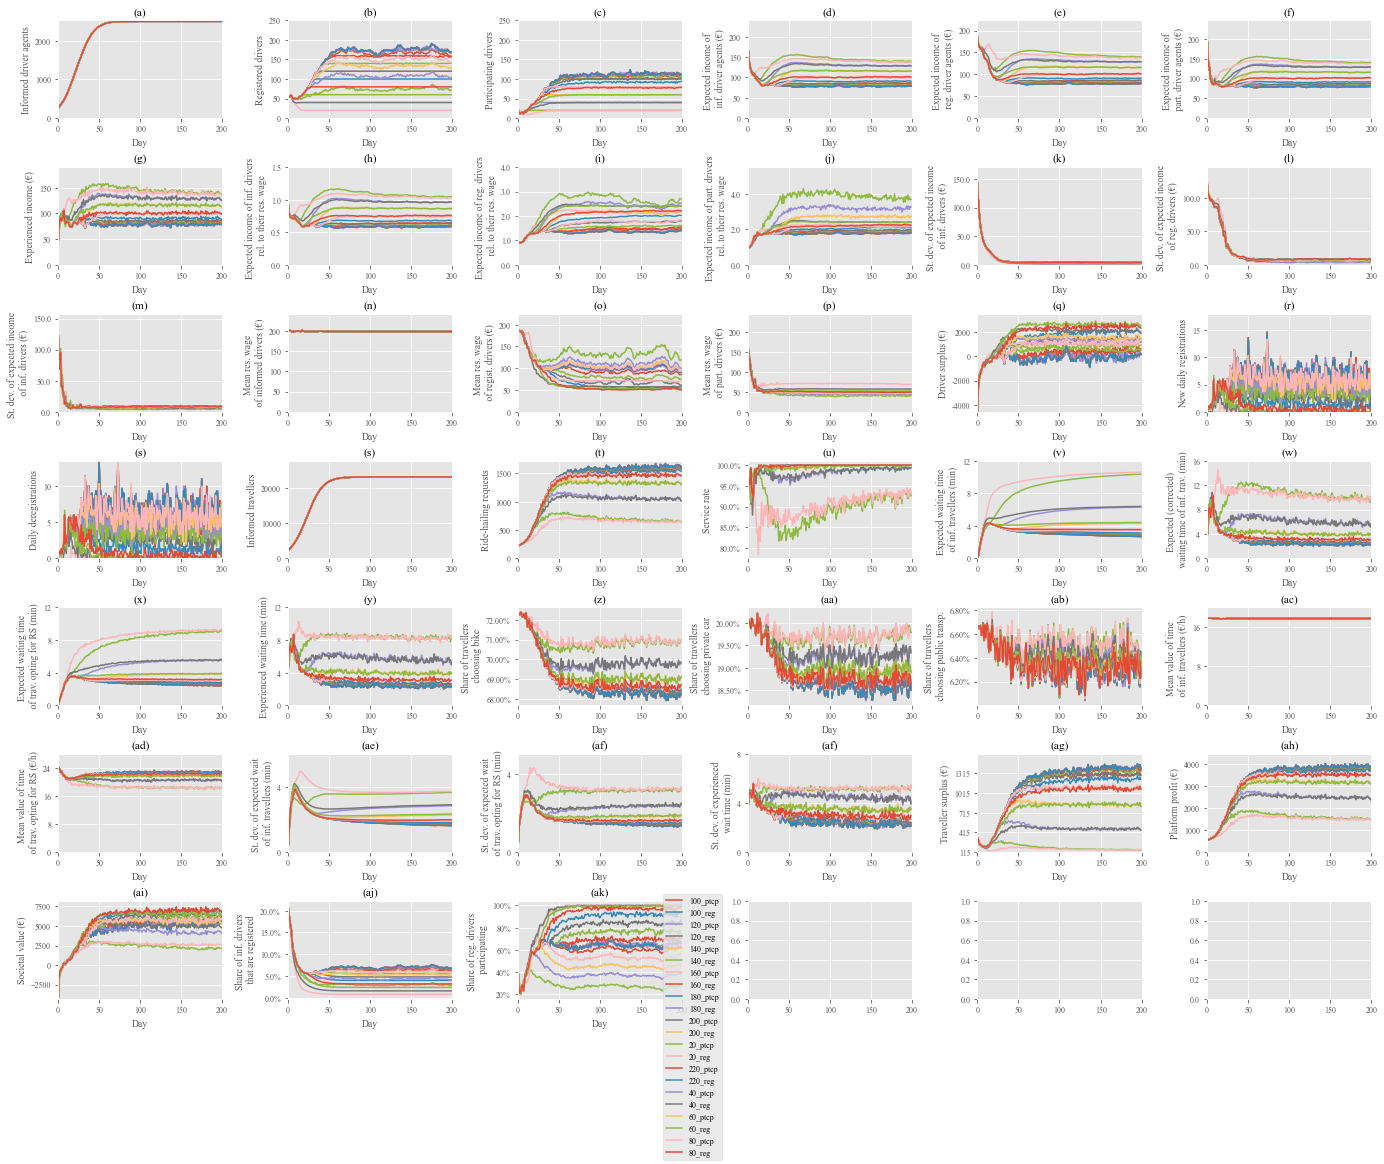

In [11]:
# Plot all indicators in one graph
fig = plot_multi_graph(res_scn, vals)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], variable["name"] + '_multi_fig.jpg'),dpi=300,bbox_inches='tight')

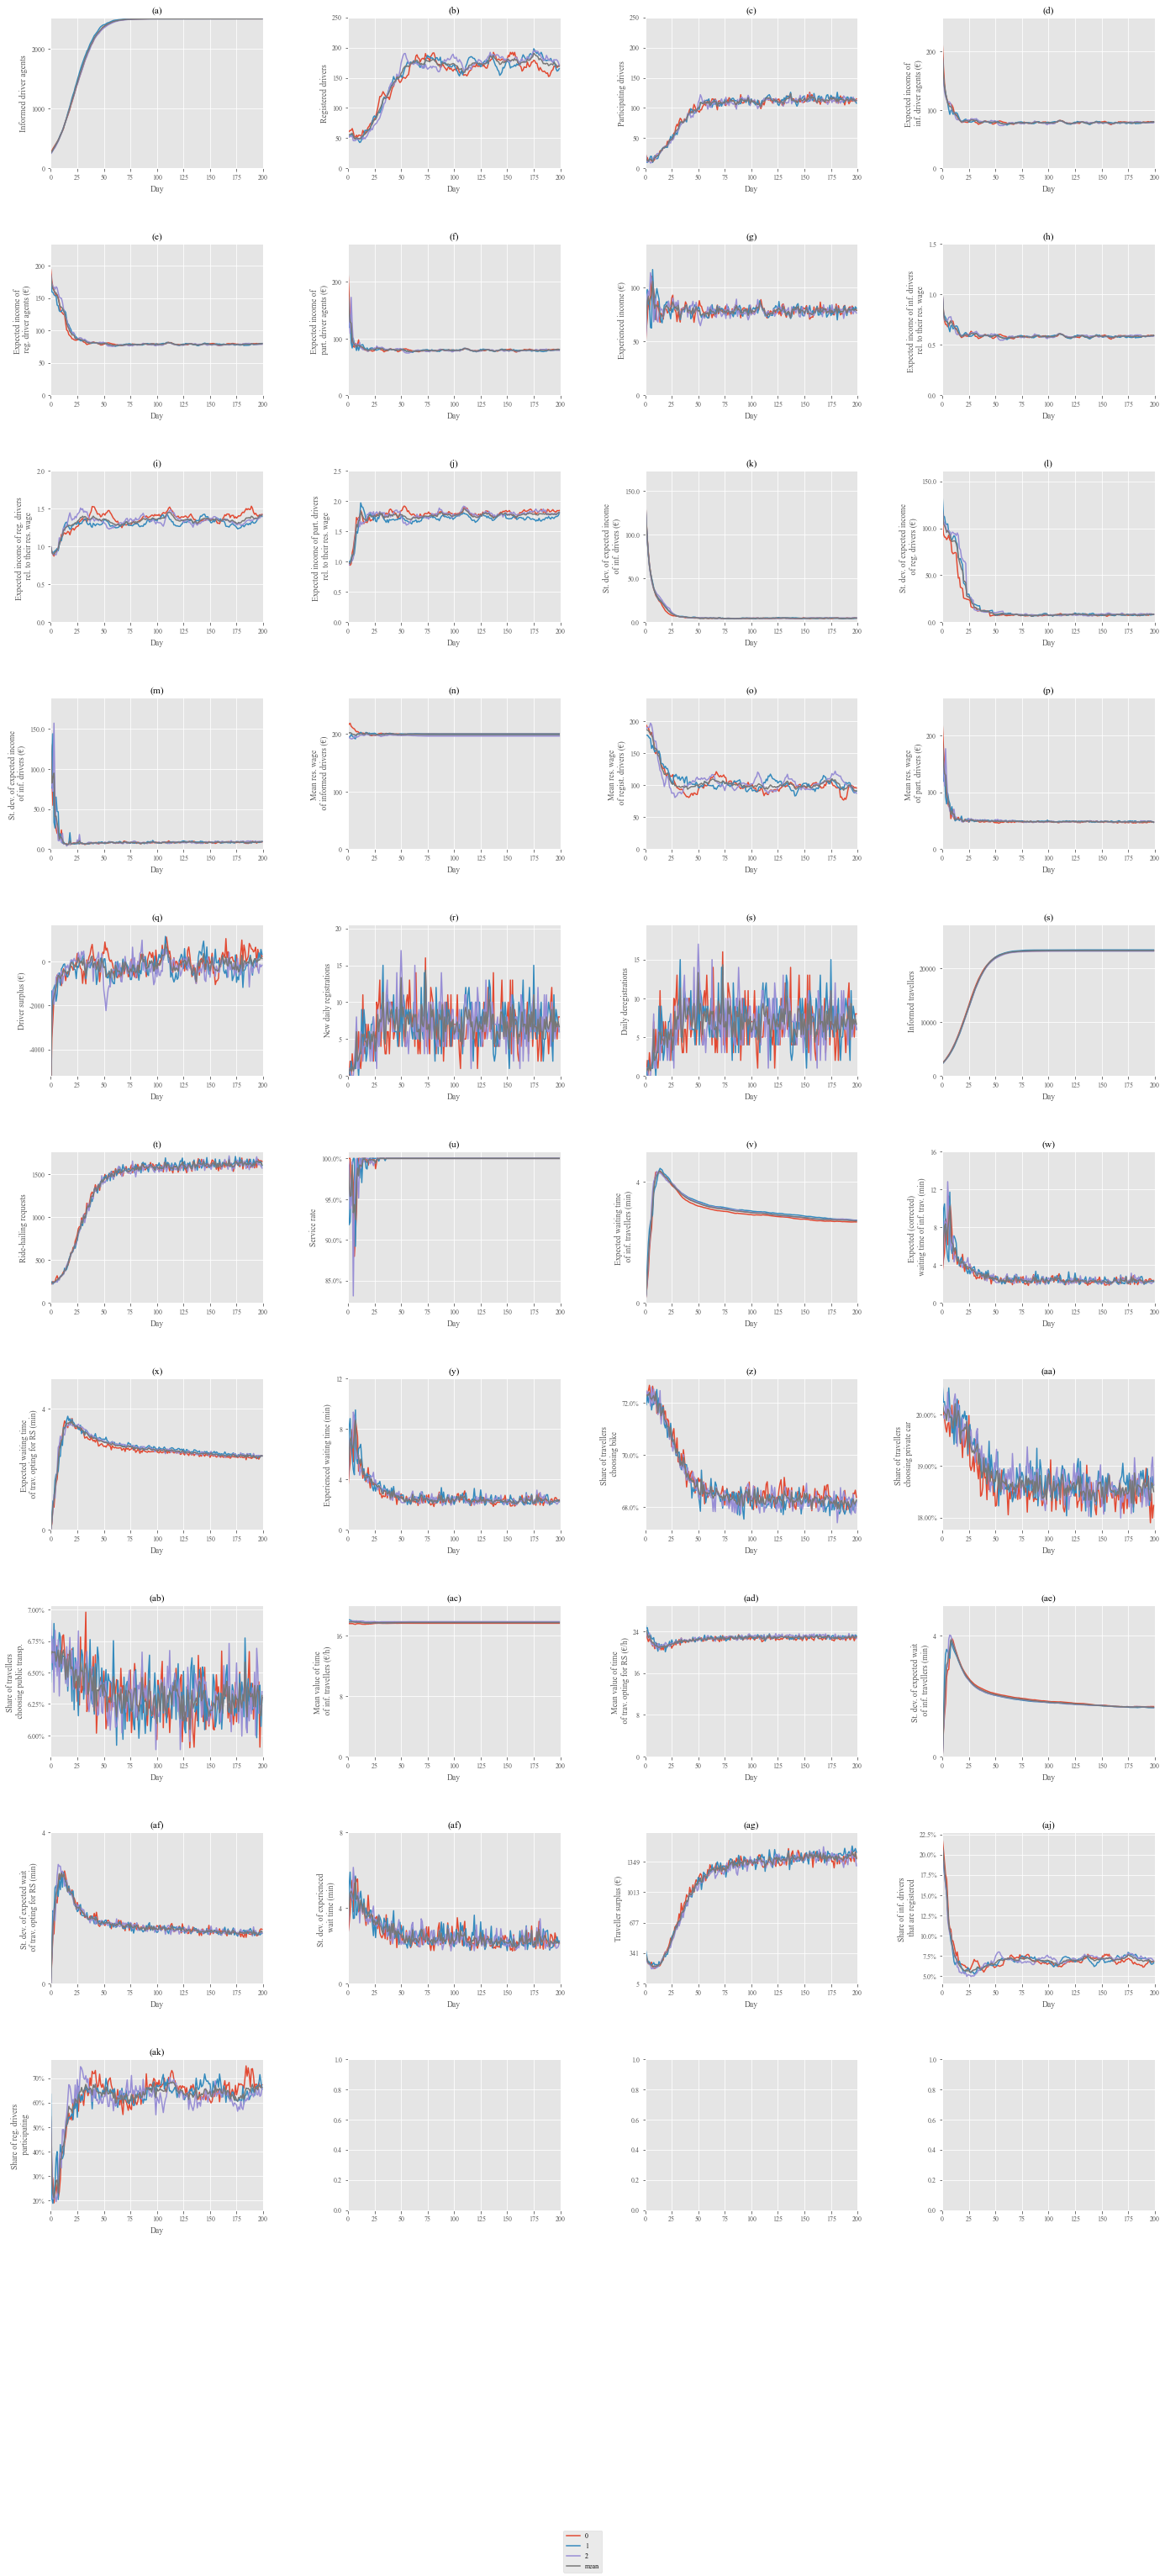

In [12]:
# Plot all runs within a single scenario - all indicators in one graph
scn_name = '200_reg'
fig = plot_multi_graph_runs(d2d.sup[scn_name], d2d.dem[scn_name])
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'run_dynamics_multi_fig.jpg'),dpi=300,bbox_inches='tight')

<AxesSubplot:xlabel='day', ylabel='Volume of informed drivers'>

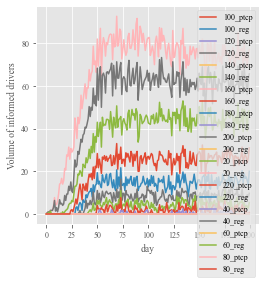

In [13]:
# Plot an individual indicator
plot_inform = res_scn.sup.rejected_reg.plot()
plot_inform.set_ylabel("Volume of informed drivers")
plot_inform

In [14]:
# kpi_eq.informed_drivers = round(kpi_eq.informed_drivers).astype(int)
# kpi_eq.regist_drivers = round(kpi_eq.regist_drivers).astype(int)
# kpi_eq.particip_drivers = round(kpi_eq.particip_drivers).astype(int)
# kpi_eq.requests = round(kpi_eq.requests).astype(int)
# kpi_eq.mean_perc_inc = round(kpi_eq.mean_perc_inc,2)
# kpi_eq.std_perc_inc = round(kpi_eq.std_perc_inc,2)
# kpi_eq.mean_exp_inc = round(kpi_eq.mean_exp_inc,2)
# kpi_eq.std_exp_inc = round(kpi_eq.std_exp_inc,2)
# kpi_eq.service_rate = round(kpi_eq.service_rate,1)
# kpi_eq.mean_wait_time = round(kpi_eq.mean_wait_time).astype(int)
# kpi_eq.exp_pure_wait = round(kpi_eq.exp_pure_wait).astype(int)
# kpi_eq.exp_wait_time = round(kpi_eq.exp_wait_time).astype(int)
# kpi_eq.std_perc_wait = round(kpi_eq.std_perc_wait).astype(int)
# kpi_eq.std_exp_wait = round(kpi_eq.std_exp_wait).astype(int)
# kpi_eq.std_corr_exp_wait = round(kpi_eq.std_corr_exp_wait).astype(int)
# kpi_eq.plf_profit = round(kpi_eq.plf_profit).astype(int)
# # kpi_eq = kpi_eq.drop(['perc_pax_reject'],axis=1)
# kpi_eq = kpi_eq[['informed_drivers','regist_drivers','particip_drivers', 'requests','mean_perc_inc','std_perc_inc','mean_exp_inc','std_exp_inc','service_rate','mean_wait_time','std_perc_wait','exp_pure_wait','std_exp_wait','exp_wait_time','std_corr_exp_wait','plf_profit']]

# Print equilibrium indicators as LateX table
print(eql_scn.sup.astype('str').T.to_latex(index=True))
print(eql_scn.dem.astype('str').T.to_latex(index=True))
print(eql_scn.plf.astype('str').T.to_latex(index=True))

\begin{tabular}{lllllllllllllllllllllll}
\toprule
scenario &            100\_ptcp &             100\_reg &             120\_ptcp &             120\_reg &            140\_ptcp &             140\_reg &            160\_ptcp &             160\_reg &            180\_ptcp &             180\_reg &            200\_ptcp &             200\_reg &             20\_ptcp &              20\_reg &            220\_ptcp &             220\_reg &             40\_ptcp &              40\_reg &             60\_ptcp &              60\_reg &             80\_ptcp &              80\_reg \\
\midrule
inform             &              2500.0 &              2500.0 &               2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &              2500.0 &     

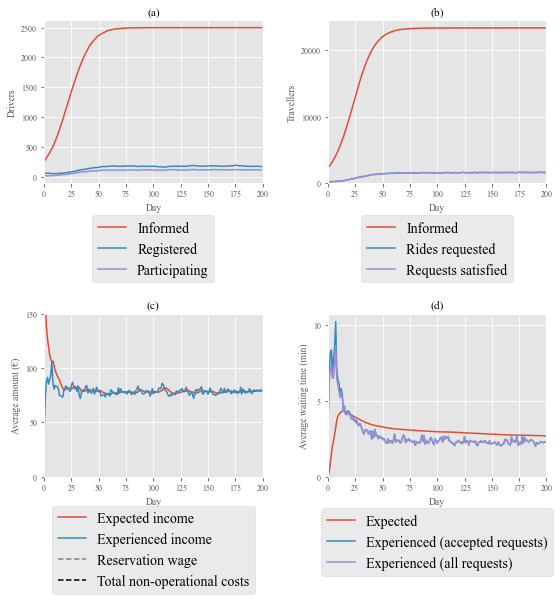

In [15]:
# Plot indicators for single scenario (e.g. base scenario)
value = '200_reg' # specific scenario
fig = plot_single_scenario(res_scn, value)
fig.savefig(os.path.join(os.getcwd(),"plots",'base_scenario'+'.jpg'), bbox_inches='tight', dpi=300)

---

In [16]:
# KPIs
kpis_sup = eql_scn.sup.columns
kpis_dem = eql_scn.dem.columns
kpis_plf = ['plat_profit']

In [17]:
# Find societal value
eql_scn.soc = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
eql_scn.soc = pd.DataFrame(eql_scn.soc.values, index = vals, columns = ['soc_value'])

In [18]:
eql_scn_reg = DotMap()
eql_scn_ptcp = DotMap()
eql_scn.sup['cap'] = eql_scn.sup.index
eql_scn.sup['cap_type'] = eql_scn.sup.cap.str.split('_').apply(lambda x: x[1])
eql_scn.sup['cap_quant'] = eql_scn.sup.cap.str.split('_').apply(lambda x: x[0]).astype(int)
eql_scn_reg.sup = eql_scn.sup[eql_scn.sup.cap_type == 'reg']
eql_scn_reg.sup.set_index('cap_quant', inplace=True)
eql_scn_reg.sup = eql_scn_reg.sup.sort_index()
eql_scn_ptcp.sup = eql_scn.sup[eql_scn.sup.cap_type == 'ptcp']
eql_scn_ptcp.sup.set_index('cap_quant', inplace=True)
eql_scn_ptcp.sup = eql_scn_ptcp.sup.sort_index()
eql_scn.dem['cap'] = eql_scn.dem.index
eql_scn.dem['cap_type'] = eql_scn.dem.cap.str.split('_').apply(lambda x: x[1])
eql_scn.dem['cap_quant'] = eql_scn.dem.cap.str.split('_').apply(lambda x: x[0]).astype(int)
eql_scn_reg.dem = eql_scn.dem[eql_scn.dem.cap_type == 'reg']
eql_scn_reg.dem.set_index('cap_quant', inplace=True)
eql_scn_reg.dem = eql_scn_reg.dem.sort_index()
eql_scn_ptcp.dem = eql_scn.dem[eql_scn.dem.cap_type == 'ptcp']
eql_scn_ptcp.dem.set_index('cap_quant', inplace=True)
eql_scn_ptcp.dem = eql_scn_ptcp.dem.sort_index()
eql_scn.soc['cap'] = eql_scn.soc.index
eql_scn.soc['cap_type'] = eql_scn.soc.cap.str.split('_').apply(lambda x: x[1])
eql_scn.soc['cap_quant'] = eql_scn.soc.cap.str.split('_').apply(lambda x: x[0]).astype(int)
eql_scn_reg.soc = eql_scn.soc[eql_scn.soc.cap_type == 'reg']
eql_scn_reg.soc.set_index('cap_quant', inplace=True)
eql_scn_reg.soc = eql_scn_reg.soc.sort_index()
eql_scn_ptcp.soc = eql_scn.soc[eql_scn.soc.cap_type == 'ptcp']
eql_scn_ptcp.soc.set_index('cap_quant', inplace=True)
eql_scn_ptcp.soc = eql_scn_ptcp.soc.sort_index()
eql_scn.plf['cap'] = eql_scn.plf.index
eql_scn.plf['cap_type'] = eql_scn.plf.cap.str.split('_').apply(lambda x: x[1])
eql_scn.plf['cap_quant'] = eql_scn.plf.cap.str.split('_').apply(lambda x: x[0]).astype(int)
eql_scn_reg.plf = eql_scn.plf[eql_scn.plf.cap_type == 'reg']
eql_scn_reg.plf.set_index('cap_quant', inplace=True)
eql_scn_reg.plf = eql_scn_reg.plf.sort_index()
eql_scn_ptcp.plf = eql_scn.plf[eql_scn.plf.cap_type == 'ptcp']
eql_scn_ptcp.plf.set_index('cap_quant', inplace=True)
eql_scn_ptcp.plf = eql_scn_ptcp.plf.sort_index()

In [96]:
eql_scn_reg.sup

,inform,regist,rejected_reg,particip,reject_particip,mean_perc_inc,mean_perc_inc_ptcp,mean_perc_inc_reg,mean_exp_inc,rel_perc_inc,...,std_perc_inc_reg,std_perc_inc_ptcp,res_wage_inf,res_wage_reg,res_wage_ptcp,new_regist,deregist,driver_surplus,cap,cap_type
cap_quant,,,,,,,,,,,,,,,,,,,,,
20,2500.0,20.000000,73.466667,20.000000,0.0,137.749863,137.772826,137.772826,137.376225,1.028625,...,4.841953,4.841953,198.988276,68.995902,68.995902,0.000000,0.000000,967.606466,20_reg,reg
40,2500.0,40.000000,61.666667,39.933333,0.0,128.956946,128.966122,128.960108,128.509832,0.963028,...,5.612784,5.615075,198.988276,57.255258,57.222308,0.000000,0.000000,2046.545284,40_reg,reg
60,2500.0,60.000000,45.600000,59.866667,0.0,115.872586,115.901822,115.872681,115.520012,0.865182,...,7.442344,7.424166,198.988276,52.247042,52.221514,0.000000,0.000000,2589.393415,60_reg,reg
80,2500.0,80.000000,27.200000,78.266667,0.0,101.731012,102.199775,102.086353,100.525253,0.759840,...,8.582442,8.568125,198.988276,51.117785,49.485543,0.666667,0.666667,2393.427431,80_reg,reg
100,2500.0,100.000000,16.666667,93.200000,0.0,91.428033,91.709749,91.464352,90.173395,0.682834,...,8.933220,8.888302,198.988276,53.420282,47.293149,1.066667,1.066667,1993.941286,100_reg,reg
120,2500.0,120.000000,8.000000,102.133333,0.0,85.854275,86.789601,85.954846,84.791472,0.640906,...,9.186028,8.612381,198.988276,62.896785,47.433248,3.133333,3.133333,1407.582641,120_reg,reg
140,2500.0,140.000000,3.600000,106.333333,0.0,82.375813,83.420629,82.366731,82.875690,0.614905,...,9.436533,9.064369,198.988276,75.740476,47.758582,5.133333,5.133333,928.536732,140_reg,reg
160,2500.0,157.066667,0.533333,110.466667,0.0,81.012924,82.169936,81.084182,80.520959,0.604730,...,8.706277,8.438642,198.988276,86.881832,48.423314,6.733333,7.066667,393.424631,160_reg,reg
180,2500.0,168.266667,0.000000,111.600000,0.0,79.038750,80.314272,78.874341,80.361294,0.589909,...,8.857161,8.752423,198.988276,91.346668,48.163171,6.533333,7.800000,217.903421,180_reg,reg


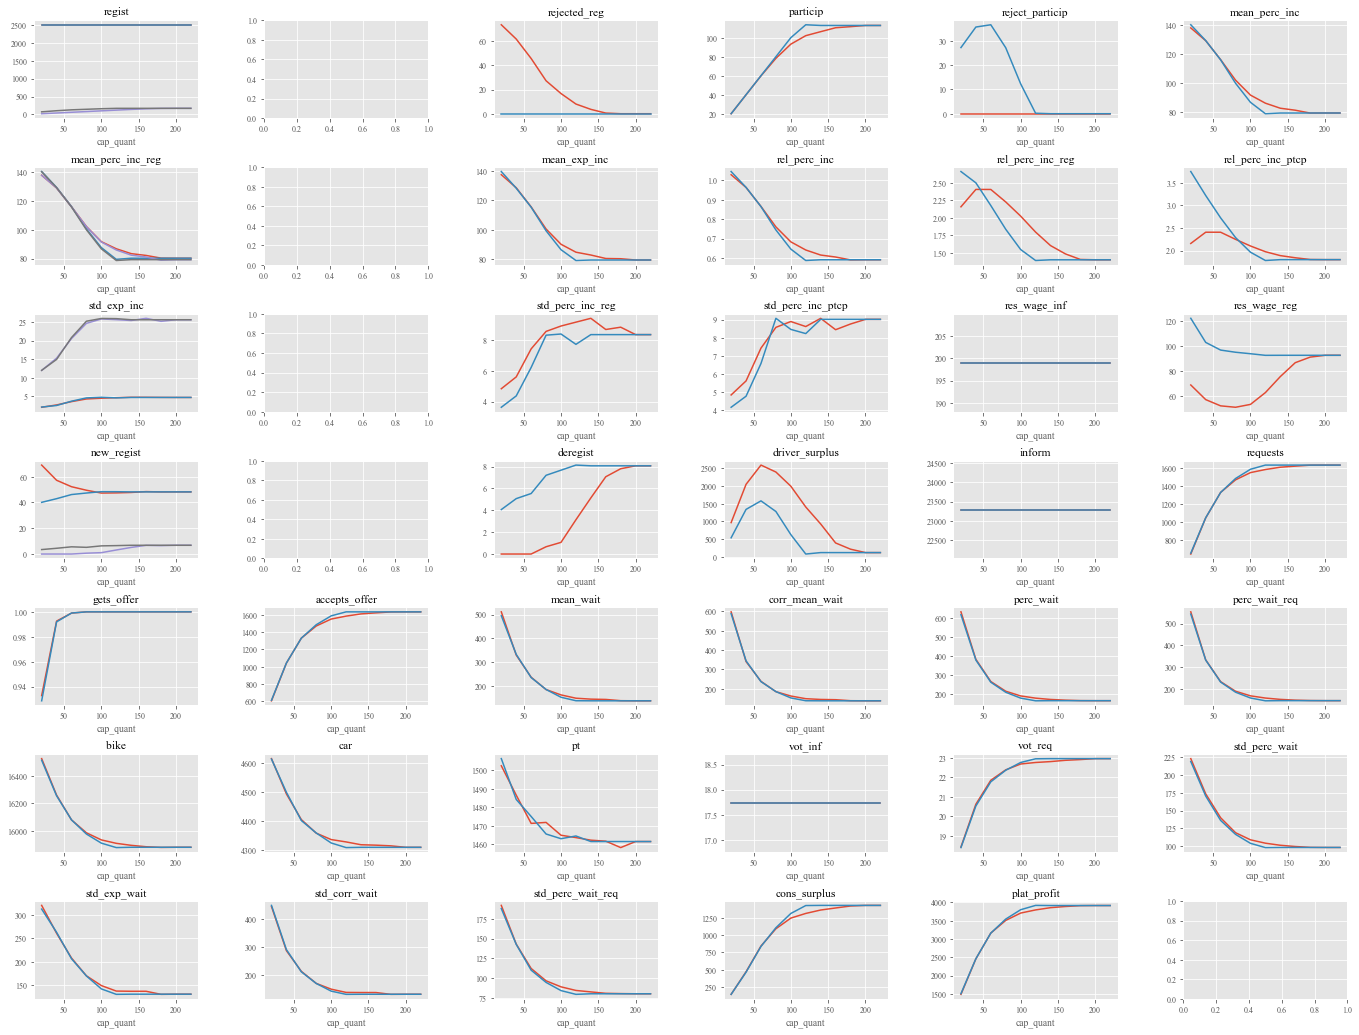

In [20]:
fig, axes = plt.subplots(7, 6, figsize = [24,18])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.4, left=.12, right=.88)
i = 0
j = 0

for kpi in kpis_sup:
    axes[j, i] = eql_scn_reg.sup[kpi].plot(ax=axes[j,i])
    axes[j, 1] = eql_scn_ptcp.sup[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_dem:
    axes[j, i] = eql_scn_reg.dem[kpi].plot(ax=axes[j,i])
    axes[j, i] = eql_scn_ptcp.dem[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

for kpi in kpis_plf:
    axes[j, i] = eql_scn_reg.plf[kpi].plot(ax=axes[j,i])
    axes[j, i] = eql_scn_ptcp.plf[kpi].plot(ax=axes[j,i])
    axes[j, i].set_title(kpi)
    i += 1
    if i > 5:
        i = 0
        j += 1

fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'effect.jpg'),dpi=300,bbox_inches='tight')


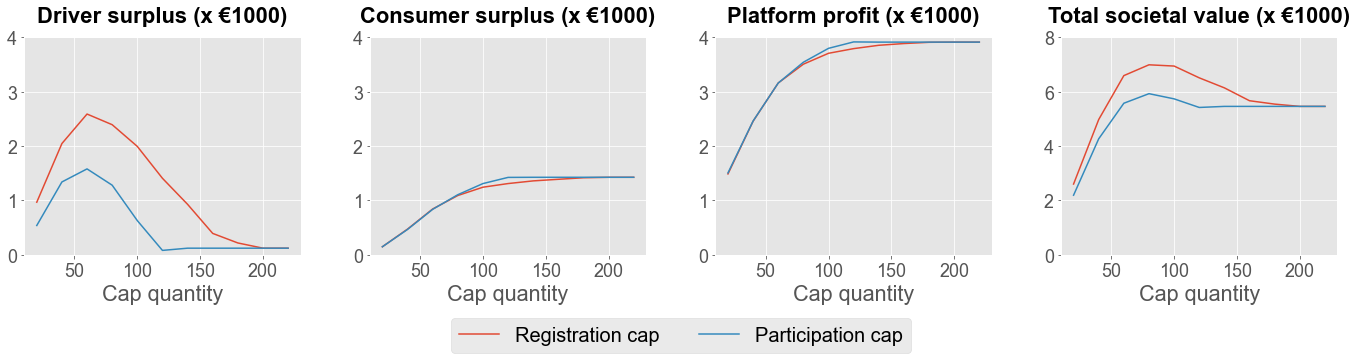

In [91]:
# Plot societal indicators
font = {'family': 'arial',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)
plt.rc('xtick', labelsize=18)    # fontsize of the tick labels
plt.rc('ytick', labelsize=18)
# plt.rcParams['font.weight'] = "normal"
# plt.rcParams.update({'font.size': 16})

fig, axes = plt.subplots(1, 4, figsize = [24,4])
    # plt.subplots_adjust(top=.9, bottom=.1, hspace=.1, left=.1, right=.9, wspace=.1)
fig.subplots_adjust(hspace=.5, wspace=0.25, left=.12, right=.88)

axes[0] = (eql_scn_reg.sup.driver_surplus / 1000).plot(ax=axes[0])
axes[0] = (eql_scn_ptcp.sup.driver_surplus / 1000).plot(ax=axes[0])
axes[0].set_title('Driver surplus (x \u20ac1000)', fontweight="bold", pad=15, fontsize=22)
axes[0].set_xlabel('Cap quantity')
axes[0].set_ylim(bottom = 0, top = 4) 
# axes[0].set_ylabel('Registration cap')

axes[1] = (eql_scn_reg.dem.cons_surplus / 1000).plot(ax=axes[1])
axes[1] = (eql_scn_ptcp.dem.cons_surplus / 1000).plot(ax=axes[1])
axes[1].set_title('Consumer surplus (x \u20ac1000)', fontweight="bold", pad=15, fontsize=22)
axes[1].set_xlabel('Cap quantity')
axes[1].set_ylim(bottom = 0, top = 4) 

axes[2] = (eql_scn_reg.plf.plat_profit / 1000).plot(ax=axes[2])
axes[2] = (eql_scn_ptcp.plf.plat_profit / 1000).plot(ax=axes[2])
axes[2].set_title('Platform profit (x \u20ac1000)', fontweight="bold", pad=15, fontsize=22)
axes[2].set_xlabel('Cap quantity')
axes[2].set_ylim(bottom = 0, top = 4) 

axes[3] = (eql_scn_reg.soc.soc_value / 1000).plot(ax=axes[3])
axes[3] = (eql_scn_ptcp.soc.soc_value / 1000).plot(ax=axes[3])
axes[3].set_title('Total societal value (x \u20ac1000)', fontweight="bold", pad=15, fontsize=22)
axes[3].set_xlabel('Cap quantity')
axes[3].set_ylim(bottom = 0, top = 8) 

fig.legend(['Registration cap','Participation cap'], ncol=2, loc='lower center',title=False,fontsize=20, bbox_to_anchor=(0.5, -0.25)) #bbox_to_anchor=(0.7, 0.5)
fig.savefig(os.path.join(os.getcwd(),"plots",variable["name"], 'societal_value.jpg'),dpi=300,bbox_inches='tight')

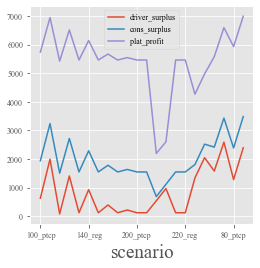

In [22]:
soc_val = pd.DataFrame()
soc_val['driver_surplus'] = eql_scn.sup.driver_surplus
soc_val['cons_surplus'] = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus
soc_val['plat_profit'] = eql_scn.sup.driver_surplus + eql_scn.dem.cons_surplus + eql_scn.plf.plat_profit
ax1 = soc_val.plot()
# ax1.fill_between('driver_surplus', 0, 'plat_profit')

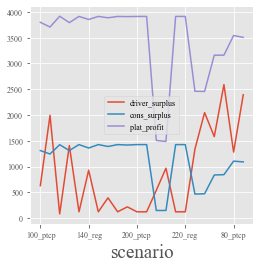

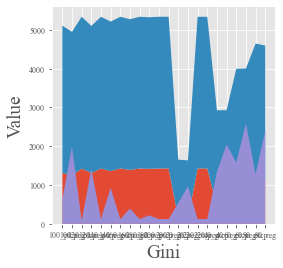

In [23]:
soc_val = pd.DataFrame()
soc_val['driver_surplus'] = eql_scn.sup.driver_surplus
soc_val['cons_surplus'] = eql_scn.dem.cons_surplus
soc_val['plat_profit'] = eql_scn.plf.plat_profit
ax1 = soc_val.plot()

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.stackplot(soc_val.index, soc_val.cons_surplus, soc_val.plat_profit)
ax.stackplot(soc_val.index, soc_val.driver_surplus)
ax.set_xlabel("Gini")
ax.set_ylabel("Value")
# ax.set_ylim(bottom=-0.5, top=1.5)
# ax.grid(which="major", color="grey", linestyle="--", linewidth=0.5)

plt.show()

In [24]:
requests[50].VoT.max()

134.6148728258877

In [25]:
micro.sup.inform[5]

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
veh,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
5,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2496,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2497,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,True
2498,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [26]:
np.exp(-25)

1.3887943864964021e-11

In [27]:
np.exp(-100)

3.720075976020836e-44

In [28]:
np.exp(-1000)

0.0

In [29]:
np.log(np.exp(-1000))

<ipython-input-29-96ba8be81176>:1: RuntimeWarning: divide by zero encountered in log
  np.log(np.exp(-1000))


-inf

In [30]:
res.dem[50]

,inform,requests,gets_offer,accepts_offer,mean_wait,corr_mean_wait,perc_wait,perc_wait_req,bike,car,pt,vot_inf,vot_req,std_perc_wait,std_exp_wait,std_corr_wait,std_perc_wait_req,cons_surplus
day,,,,,,,,,,,,,,,,,,
0,2304,233,1.000000,233,211.648069,211.648069,0.000000,0.000000,16715,4636,1603,17.805369,23.675088,0.000000,135.383408,135.383408,0.000000,299.605154
1,2499,228,0.991228,226,332.840708,345.710526,18.670164,15.223085,16805,4629,1525,17.779720,24.327134,53.820786,262.111664,294.781464,43.211831,296.105148
2,2715,226,0.955752,216,410.337963,471.827434,44.900917,38.198908,16774,4618,1569,17.803941,23.160799,93.616844,275.690369,393.266815,80.591454,236.271598
3,2963,249,0.943775,235,425.148936,502.449799,80.391619,69.383122,16795,4676,1467,17.826748,23.097834,139.652954,300.301025,431.040680,113.127387,237.759286
4,3196,236,0.978814,231,462.593074,490.927966,111.592733,60.502968,16740,4624,1587,17.897620,23.825769,167.146622,307.533325,360.298126,96.613940,218.954852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,23187,653,0.926493,605,525.419835,619.110260,630.596643,552.640304,16403,4603,1528,17.833626,18.277103,219.072769,340.815216,467.345154,189.618487,151.591795
196,23187,640,0.940625,602,509.923588,586.521875,630.971033,555.376617,16502,4558,1487,17.833626,18.468781,219.181320,327.948914,440.738556,191.281192,143.807287
197,23187,628,0.952229,598,547.249164,607.093949,631.142965,547.139299,16405,4661,1493,17.833626,19.205232,219.368896,329.358643,418.078796,170.108204,146.366854


In [31]:
micro.dem.wait_time[50]

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
pax_id,,,,,,,,,,,,,,,,,,,,,
0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,478.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23183.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23184.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(0.0, 500.0)

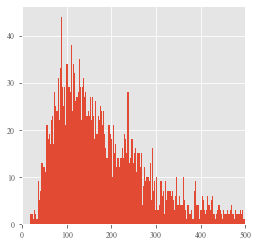

In [32]:
ax1 = drivers[50].res_wage.hist(bins=500)
ax1.set_xlim([0, 500])

(0.0, 500.0)

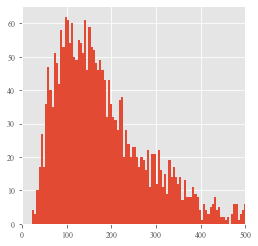

In [33]:
ax1 = drivers[55].res_wage.hist(bins=500)
ax1.set_xlim([0, 500])

In [34]:
variable['name']

'reg_cap'

In [35]:
micro.dem.wait_time[2]

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
pax_id,,,,,,,,,,,,,,,,,,,,,
0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.0,NaN
2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,431.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,321.0,NaN,NaN,NaN,NaN,NaN,NaN,358.0
4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,71.0,NaN,NaN,NaN,NaN,NaN,NaN,179.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23183.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23184.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
micro.dem.wait_time[2]

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
pax_id,,,,,,,,,,,,,,,,,,,,,
0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.0,NaN
2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,431.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,321.0,NaN,NaN,NaN,NaN,NaN,NaN,358.0
4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,71.0,NaN,NaN,NaN,NaN,NaN,NaN,179.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23183.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23184.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
d2d.sup[220]

DotMap(_ipython_display_=DotMap(), _repr_mimebundle_=DotMap())

In [38]:
vals

['100_ptcp',
 '100_reg',
 '120_ptcp',
 '120_reg',
 '140_ptcp',
 '140_reg',
 '160_ptcp',
 '160_reg',
 '180_ptcp',
 '180_reg',
 '200_ptcp',
 '200_reg',
 '20_ptcp',
 '20_reg',
 '220_ptcp',
 '220_reg',
 '40_ptcp',
 '40_reg',
 '60_ptcp',
 '60_reg',
 '80_ptcp',
 '80_reg']

In [39]:
a = 0
for i in range(0,len(res.sup)):
    one_ptcp = (res.sup[i].particip == 0)
    if one_ptcp.any():
        print('run_id {} has day with 1 participant - scenario {}'.format(i,scn.val[i]))
        a += 1

In [40]:
d2d.sup['220_reg'].mean_perc_inc.head(50)

,0,1,2,mean,stdev
day,,,,,
0,215.059495,194.508847,191.533129,200.367157,12.810633
1,174.133226,153.085376,154.279834,160.499479,11.822266
2,145.155157,139.741021,131.221316,138.705832,7.024364
3,128.427506,129.848739,122.725093,127.000446,3.770140
4,121.114496,119.285511,117.789137,119.396382,1.665450
5,113.056898,111.548115,112.716563,112.440525,0.791362
6,109.779855,100.897881,114.276661,108.318132,6.808114
7,111.049897,92.483326,113.172958,105.568727,11.381899
8,110.512412,99.538448,109.829620,106.626827,6.148202
